<a href="https://colab.research.google.com/github/emiliomercuri/EnvHydrology2026/blob/main/Aulas/Aula13_agua_subsuperficial/Importando_base_FLDAS_Soil_Moisture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Faz a leitura de arquivos de FLDAS - Soil Moisture

ClimateEngine (Root Zone Soil Moisture 0-100cm) - recorte na Bacia Hidrogrática do rio Purus


No FLDAS (Noah LSM), a variável:

👉 Root Zone Soil Moisture (0–100 cm)

tem unidade:

kg/m² (quilogramas por metro quadrado)

📐 Conversão prática

Se você quiser trabalhar em termos hidrológicos (como no GR2M ou balanço hídrico):

Soil Moisture (mm)=Soil Moisture (kg/m²)

✔ Ou seja:

não precisa converter → já está em mm



In [1]:
import pandas as pd
import numpy
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

In [4]:
# Baixa dados da base FLDAS
!gdown 1cil6o2OdRagKdLzSrC_Kz_2DsU3b09c2

# Baixa dados da base CHIRPS
!gdown 1Z9SQGph3kOU3GafkUrmM1_6lVI9VHFP6

Downloading...
From: https://drive.google.com/uc?id=1cil6o2OdRagKdLzSrC_Kz_2DsU3b09c2
To: /content/ClimateEngine (Root Zone Soil Moisture 0-100cm) - Purus.csv
100% 6.95k/6.95k [00:00<00:00, 29.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z9SQGph3kOU3GafkUrmM1_6lVI9VHFP6
To: /content/ClimateEngine_Purus_CHIRPS.csv
100% 312k/312k [00:00<00:00, 6.22MB/s]


In [3]:
# dados da base FLDAS
Purus_Umidade = pd.read_csv('ClimateEngine (Root Zone Soil Moisture 0-100cm) - Purus.csv',
                          sep=';', index_col=[0])
Purus_Umidade.index=pd.to_datetime(Purus_Umidade.index)
Purus_Umidade = Purus_Umidade.replace(regex={',': '.'}).astype(float)
Purus_Umidade

,"(mm) Root Zone Soil Moisture (0-100cm) (FLDAS) at 1, 2000-01-01 to 2026-02-01"
2000-01-01,426.7031
2000-02-01,436.8041
2000-03-01,437.1682
2000-04-01,435.8579
2000-05-01,432.4026
...,...
2025-10-01,323.6641
2025-11-01,346.5203
2025-12-01,384.4628
2026-01-01,418.7441


In [5]:
# dados da base CHIRPS
Purus_CHIRPS = pd.read_csv('ClimateEngine_Purus_CHIRPS.csv',
                          sep=';', index_col=[0])
Purus_CHIRPS.index=pd.to_datetime(Purus_CHIRPS.index)
Purus_CHIRPS = Purus_CHIRPS.replace(regex={',': '.'}).astype(float)
Purus_CHIRPS

,"(mm) Precipitation (CHIRPS) at CE_ID_1, 1981-01-01 to 2024-03-31"
1981-01-01,10.8982
1981-01-02,11.2424
1981-01-03,15.9600
1981-01-04,13.6556
1981-01-05,25.4458
...,...
2024-03-27,8.4028
2024-03-28,3.7962
2024-03-29,10.2344
2024-03-30,4.5556


In [6]:
!gdown 1f0F4ut_AxhpKEa_F6nMMxqrQADAMnzUZ

Downloading...
From: https://drive.google.com/uc?id=1f0F4ut_AxhpKEa_F6nMMxqrQADAMnzUZ
To: /content/prec_espacializada_Purus.csv
100% 855k/855k [00:00<00:00, 10.6MB/s]


In [7]:
# Dados de pluviômetros
Purus_pluviom = pd.read_csv('prec_espacializada_Purus.csv',
                          sep=',', index_col=[0])
Purus_pluviom.index=pd.to_datetime(Purus_pluviom.index)
Purus_pluviom


,1068000,966000,963001,867001,765000,770000,668000,567001,media aritmetica,media thiessen
data,,,,,,,,,,
1980-01-01,20.5,20.6,0.0,18.0,15.2,0.0,30.4,4.4,13.917537,16.437869
1980-01-02,0.0,0.0,0.0,0.0,16.4,0.0,0.0,22.6,4.763248,3.757479
1980-01-03,0.0,0.0,2.2,0.0,0.0,0.0,0.0,23.8,2.928962,0.039620
1980-01-04,0.0,1.0,6.4,14.0,0.0,10.3,0.0,0.0,3.970107,4.038569
1980-01-05,0.0,1.2,0.6,0.0,5.2,21.1,0.0,0.0,3.543286,3.820360
...,...,...,...,...,...,...,...,...,...,...
2010-12-27,0.0,0.0,0.0,3.1,1.6,0.0,11.3,56.3,8.277432,1.436818
2010-12-28,0.0,66.2,39.0,0.0,0.7,0.0,0.0,41.0,17.139076,6.128264
2010-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,3.712500,0.000000


In [12]:
# Cria DataFrame contendo as duas colunas
df = pd.DataFrame()

df['prec_CHIRPS(mm)'] = Purus_CHIRPS['1981-01-01':'2010-12-31']
df['prec_Thiessen(mm)'] = Purus_pluviom['1981-01-01':'2010-12-31']['media thiessen']
df

,prec_CHIRPS(mm),prec_Thiessen(mm)
1981-01-01,10.8982,5.376438
1981-01-02,11.2424,22.177539
1981-01-03,15.9600,14.650725
1981-01-04,13.6556,20.789195
1981-01-05,25.4458,25.131866
...,...,...
2010-12-27,10.1868,1.436818
2010-12-28,3.0995,6.128264
2010-12-29,3.0987,0.000000
2010-12-30,15.1228,4.244472


In [13]:
df.isna().sum()

,0
prec_CHIRPS(mm),0
prec_Thiessen(mm),0


In [14]:
df_mensal = df.resample('ME').sum()
df_mensal

,prec_CHIRPS(mm),prec_Thiessen(mm)
1981-01-31,297.2629,265.325663
1981-02-28,274.4086,348.481941
1981-03-31,302.6189,305.734917
1981-04-30,182.6908,186.577339
1981-05-31,128.3054,146.716908
...,...,...
2010-08-31,33.7505,17.074537
2010-09-30,82.6107,70.304852
2010-10-31,184.6774,135.107554
2010-11-30,214.2130,212.135918


In [21]:
Purus_Umidade = Purus_Umidade.resample('ME').sum()
Purus_Umidade

,"(mm) Root Zone Soil Moisture (0-100cm) (FLDAS) at 1, 2000-01-01 to 2026-02-01"
2000-01-31,426.7031
2000-02-29,436.8041
2000-03-31,437.1682
2000-04-30,435.8579
2000-05-31,432.4026
...,...
2025-10-31,323.6641
2025-11-30,346.5203
2025-12-31,384.4628
2026-01-31,418.7441


In [23]:
df_mensal['Umid_FLDAS(mm)'] = Purus_Umidade
df_mensal = df_mensal['2000':]
df_mensal

,prec_CHIRPS(mm),prec_Thiessen(mm),Umid_FLDAS(mm)
2000-01-31,249.8791,249.456578,426.7031
2000-02-29,227.8068,198.252476,436.8041
2000-03-31,224.9650,211.034467,437.1682
2000-04-30,224.5786,216.183742,435.8579
2000-05-31,103.2675,82.589095,432.4026
...,...,...,...
2010-08-31,33.7505,17.074537,303.1303
2010-09-30,82.6107,70.304852,293.4310
2010-10-31,184.6774,135.107554,308.6333
2010-11-30,214.2130,212.135918,372.4319


<Axes: >

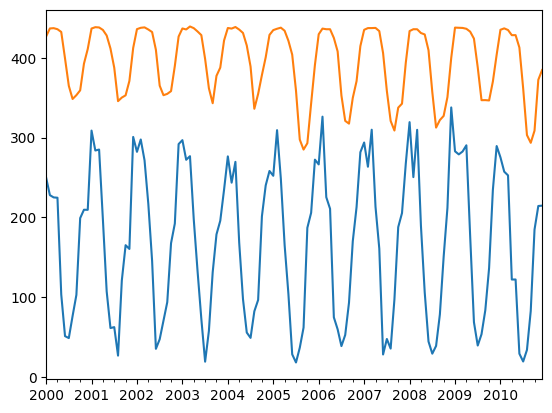

In [26]:
df_mensal['prec_CHIRPS(mm)'].plot()
df_mensal['Umid_FLDAS(mm)'].plot()